# XGBoost — Multi-Horizon WTI Forecasting

## Overview
XGBoost uses gradient-boosted decision trees that can capture nonlinear interactions and threshold effects in the predictor space. Unlike Elastic Net (linear), XGBoost can learn that "when FEDFUNDS > 4% AND credit spread widens, oil drops" without explicit feature engineering.

### Key Design Decisions
- **Why XGBoost?** The survey paper (§15) found tree-based models outperform deep learning on structured tabular data: "XGBoost offers the best balance" of accuracy and trading performance.
- **Early stopping** prevents overfitting to the noisy daily return signal.
- **Multi-horizon**: h=1, 5, 20 — same as all other models for consistent comparison.

## 1. Imports

In [1]:
# ============================================================
# Imports
# ============================================================
import numpy as np
import pandas as pd
from pathlib import Path
import pickle
import time
from abc import ABC, abstractmethod
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

## 2. Base Forecast Model

In [2]:
# ============================================================
# Base Forecast Model
# ============================================================
class BaseForecastModel(ABC):
    def __init__(self, task_type: str):
        self.task_type = task_type
    @abstractmethod
    def fit(self, *args, **kwargs): pass
    @abstractmethod
    def predict(self, X): pass
    @abstractmethod
    def evaluate(self, X, y): pass
    @abstractmethod
    def save(self, filepath: str): pass
    @abstractmethod
    def load(self, filepath: str): pass

## 3. Evaluation Metrics

In [3]:
# ============================================================
# Evaluation Metrics
# ============================================================
def rmse(y, yhat):
    """Root Mean Squared Error."""
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    return float(np.sqrt(np.mean((y - yhat) ** 2)))

def mae(y, yhat):
    """Mean Absolute Error."""
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    return float(np.mean(np.abs(y - yhat)))

def r2(y, yhat):
    """R-squared. Negative = worse than predicting the mean."""
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    ss_tot = np.sum((y - y.mean()) ** 2)
    ss_res = np.sum((y - yhat) ** 2)
    return float(1 - ss_res / ss_tot) if ss_tot > 0 else np.nan

def directional_accuracy(y, yhat):
    """Fraction where predicted and actual signs match. 50% = random."""
    y, yhat = np.asarray(y, float), np.asarray(yhat, float)
    return float(np.mean(np.sign(y) == np.sign(yhat)))

## 4. Data Helpers (Trading-Day Aligned)

In [4]:
# ============================================================
# Data Helpers (STRICT leakage control — trading-day aligned)
# ============================================================
# FIX: All models now use price.index for daily alignment
# instead of freq="D" (calendar) or freq="B" (business days).
# This ensures all models are evaluated on exactly the same dates.

def load_macro_monthly(path: Path, features: list[str]) -> pd.DataFrame:
    """Load FRED-MD monthly macro data, keeping only specified features.
    Skips the metadata row present in FRED-MD CSVs."""
    df = pd.read_csv(path, skiprows=[1]).rename(columns={"sasdate": "date"})
    df["date"] = pd.to_datetime(df["date"])
    df = df.set_index("date").sort_index()
    keep = [c for c in features if c in df.columns]
    missing = [c for c in features if c not in df.columns]
    if missing:
        print(f"[WARN] Missing macro columns (skipped): {missing}")
    return df[keep].copy()


def load_price(path: Path) -> pd.Series:
    """Load WTI crude oil daily price data (trading days only)."""
    px = pd.read_csv(path, parse_dates=["Date"])
    return px.set_index("Date")["Price"].sort_index()


def make_lagged_features(X: pd.DataFrame, L: int) -> pd.DataFrame:
    """Create L lagged versions of each column in X.
    Lag 1 = yesterday, Lag 2 = two days ago, etc."""
    return pd.concat(
        [X.shift(l).add_suffix(f"_lag{l:02d}") for l in range(1, L + 1)],
        axis=1
    ).dropna()


def daily_log_return(price: pd.Series) -> pd.Series:
    """Compute daily log returns: log(P_t) - log(P_{t-1})."""
    return np.log(price.astype(float)).diff().rename("ret_1d")


def make_target(price: pd.Series, horizon: int = 1) -> pd.Series:
    """h-day-ahead log return target: y_t = log(P_{t+h}) - log(P_t)."""
    price = price.astype(float)
    return (np.log(price.shift(-horizon)) - np.log(price)).rename("y")

## 5. Dataset Builder

In [5]:
# ============================================================
# Trading-Day Aligned Dataset Builder
# ============================================================
def build_dataset(
    macro_file: Path,
    price_file: Path,
    features: list[str],
    lookback: int = 30,
    horizon: int = 1,
    train_end: str = "2014-12-31",
    val_end: str = "2024-12-31",
):
    """Build leakage-safe train/val/test datasets aligned to WTI trading days.

    Pipeline:
        1. Load monthly macro → shift by 1 month (anti-leakage)
        2. Align to WTI trading days via forward-fill on price.index
        3. Create 30-day lagged features (flattened for tabular models)
        4. Compute h-day-ahead log return target
        5. Split chronologically

    Args:
        horizon: Forecast horizon in trading days (1, 5, or 20)
    """
    # Load macro and apply anti-leakage shift
    macro_m = load_macro_monthly(macro_file, features)
    macro_m.index = macro_m.index + pd.offsets.MonthBegin(1)

    # Load prices (trading days only)
    price = load_price(price_file)

    # FIX: Align macro directly to trading-day index (no synthetic dates)
    macro_d = macro_m.reindex(price.index, method="ffill")

    # Combine macro + price on common trading days
    base = macro_d.join(price, how="inner").dropna()

    # Add daily log return as momentum feature
    base["ret_1d"] = np.log(base["Price"]).diff()

    # Create lagged features
    X_macro = make_lagged_features(base[features], lookback)
    X_price = make_lagged_features(base[["ret_1d"]], lookback)
    X = X_macro.join(X_price).dropna()

    # Forward return target at specified horizon
    y = make_target(base["Price"], horizon=horizon)

    # Align X and y
    y = y.reindex(X.index).dropna()
    X = X.loc[y.index]

    # Chronological split
    train_end_ts = pd.Timestamp(train_end)
    val_end_ts = pd.Timestamp(val_end)
    tr = X.index <= train_end_ts
    va = (X.index > train_end_ts) & (X.index <= val_end_ts)
    te = X.index > val_end_ts

    return (
        X.loc[tr], y.loc[tr],
        X.loc[va], y.loc[va],
        X.loc[te], y.loc[te],
    )

## 6. Naive Baseline

In [6]:
# ============================================================
# Naive Baseline — Predict Zero
# ============================================================
# The naive baseline predicts zero return for all dates.
# This is equivalent to the random walk hypothesis: P_{t+h} = P_t.
# Any model that can't beat this has no predictive value.
# R² is implicitly measured against this baseline, but having explicit
# metrics makes the comparison concrete.

def naive_baseline_metrics(y):
    """Evaluate the naive 'predict zero' baseline."""
    y = np.asarray(y, float)
    pred = np.zeros_like(y)
    return {
        "rmse": rmse(y, pred),
        "mae": mae(y, pred),
        "r2": r2(y, pred),
        "directional_acc": 0.5,  # random by definition
    }

## 7. XGBoost Model Class
The model searches over tree depth, learning rate, and regularization configs using 5-fold TimeSeriesSplit CV with early stopping. The final model is trained on the full training set with the validation set controlling early stopping.

In [7]:
# ============================================================
# XGBoost Forecast Model
# ============================================================
class XGBoostForecastModel(BaseForecastModel):
    """XGBoost regression with TimeSeriesSplit CV and early stopping."""

    def __init__(self, n_splits=5, num_boost_round=3000,
                 early_stopping_rounds=50, random_state=42, n_jobs=-1):
        super().__init__("regression")
        self.n_splits = n_splits
        self.num_boost_round = num_boost_round
        self.early_stopping_rounds = early_stopping_rounds
        self.random_state = random_state
        self.n_jobs = n_jobs
        self.param_grid = [
            {"max_depth": 3, "learning_rate": 0.03, "subsample": 0.8,
             "colsample_bytree": 0.8, "min_child_weight": 1},
            {"max_depth": 4, "learning_rate": 0.03, "subsample": 0.8,
             "colsample_bytree": 0.8, "min_child_weight": 1},
            {"max_depth": 5, "learning_rate": 0.05, "subsample": 0.8,
             "colsample_bytree": 0.8, "min_child_weight": 3},
        ]
        self.model = None
        self.best_params_ = None
        self.cv_results_ = []
        self.feature_names_ = None
        self.eval_results_ = None

    def fit(self, X_train, y_train, X_val=None, y_val=None):
        """CV grid search then final training with early stopping."""
        self.feature_names_ = list(X_train.columns)
        X, y = X_train.values, y_train.values
        tscv = TimeSeriesSplit(n_splits=self.n_splits)
        best_rmse, best_params = np.inf, None

        for params in self.param_grid:
            fold_rmses = []
            for tr_idx, va_idx in tscv.split(X):
                Xtr, Xva = X[tr_idx], X[va_idx]
                ytr, yva = y[tr_idx], y[va_idx]
                m = XGBRegressor(
                    objective="reg:squarederror", n_estimators=self.num_boost_round,
                    tree_method="hist", random_state=self.random_state,
                    n_jobs=self.n_jobs, early_stopping_rounds=self.early_stopping_rounds,
                    **params)
                m.fit(Xtr, ytr, eval_set=[(Xva, yva)], verbose=False)
                fold_rmses.append(rmse(yva, m.predict(Xva)))
            mean_r = np.mean(fold_rmses)
            self.cv_results_.append({"params": params, "rmse": mean_r})
            if mean_r < best_rmse:
                best_rmse, best_params = mean_r, params

        self.best_params_ = {**best_params, "cv_rmse": best_rmse}

        # Final model on full training set
        self.model = XGBRegressor(
            objective="reg:squarederror", n_estimators=self.num_boost_round,
            tree_method="hist", random_state=self.random_state,
            n_jobs=self.n_jobs, early_stopping_rounds=self.early_stopping_rounds,
            **best_params)

        if X_val is not None and y_val is not None:
            self.model.fit(X_train.values, y_train.values,
                          eval_set=[(X_train.values, y_train.values),
                                    (X_val.values, y_val.values)], verbose=False)
            self.eval_results_ = self.model.evals_result()
        else:
            self.model.fit(X_train.values, y_train.values)
        return self

    def predict(self, X):
        return self.model.predict(X.values)

    def evaluate(self, X, y):
        p = self.predict(X)
        return {"rmse": rmse(y.values, p), "mae": mae(y.values, p),
                "r2": r2(y.values, p), "directional_acc": directional_accuracy(y.values, p)}

    def feature_importance(self, top_n=20):
        booster = self.model.get_booster()
        score = booster.get_score(importance_type="gain")
        mapped = {}
        for k, v in score.items():
            idx = int(k.replace("f", ""))
            if idx < len(self.feature_names_):
                mapped[self.feature_names_[idx]] = v
        df = pd.DataFrame({"feature": list(mapped.keys()), "importance": list(mapped.values())})
        return df.sort_values("importance", ascending=False).head(top_n).reset_index(drop=True)

    def save(self, path):
        with open(path, "wb") as f: pickle.dump(self.__dict__, f)

    def load(self, path):
        with open(path, "rb") as f: self.__dict__.update(pickle.load(f))

## 8. Configuration

In [8]:
# ============================================================
# Configuration
# ============================================================
MACRO_FILE = Path("MD_Test/2025-12-MD.csv")
PRICE_FILE = Path("Price/Price.csv")

# 31 VIP macro features spanning real activity, monetary policy,
# yield curve, credit spreads, exchange rates, and sentiment
FEATURES = [
    "RPI","W875RX1","CMRMTSPLx","IPFPNSS","USWTRADE","USTRADE","BUSLOANS",
    "CONSPI","S&P 500","S&P PE ratio","FEDFUNDS","TB3MS","TB6MS","GS1","GS5",
    "GS10","AAA","BAA","TB3SMFFM","TB6SMFFM","T1YFFM","T5YFFM","T10YFFM",
    "AAAFFM","BAAFFM","EXSZUSx","EXJPUSx","EXUSUKx","EXCAUSx",
    "PPICMM","UMCSENTx"
]

HORIZONS = [1, 5, 20]

## 9. Multi-Horizon Training

In [9]:
# ============================================================
# Multi-Horizon Training
# ============================================================
results = {}

for h in HORIZONS:
    print(f"\n{'='*60}")
    print(f"  HORIZON = {h} day(s)")
    print(f"{'='*60}")
    t0 = time.time()

    Xtr, ytr, Xva, yva, Xte, yte = build_dataset(
        MACRO_FILE, PRICE_FILE, FEATURES,
        lookback=30, horizon=h,
    )
    print(f"  Train: {Xtr.shape}  Val: {Xva.shape}  Test: {Xte.shape}")

    model = XGBoostForecastModel()
    model.fit(Xtr, ytr, X_val=Xva, y_val=yva)

    pred_val = model.predict(Xva)
    pred_test = model.predict(Xte)
    val_m = model.evaluate(Xva, yva)
    test_m = model.evaluate(Xte, yte)
    naive_val = naive_baseline_metrics(yva.values)
    naive_test = naive_baseline_metrics(yte.values)
    elapsed = time.time() - t0

    results[h] = {
        'Xtr': Xtr, 'ytr': ytr, 'Xva': Xva, 'yva': yva, 'Xte': Xte, 'yte': yte,
        'pred_val': pred_val, 'pred_test': pred_test,
        'val_metrics': val_m, 'test_metrics': test_m,
        'naive_val': naive_val, 'naive_test': naive_test,
        'model': model, 'elapsed': elapsed,
    }

    print(f"  Best params: {model.best_params_}")
    print(f"  Validation:  {val_m}")
    print(f"  Test:        {test_m}")
    print(f"  Naive (val): {naive_val}")
    print(f"  Naive (test):{naive_test}")
    print(f"  Time: {elapsed:.1f}s")
    model.save(f"xgboost_wti_h{h}.pkl")

print("\nAll horizons complete.")


  HORIZON = 1 day(s)
  Train: (7953, 960)  Val: (2635, 960)  Test: (215, 960)
  Best params: {'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'cv_rmse': np.float64(0.023563471050765124)}
  Validation:  {'rmse': 0.030803280416137484, 'mae': 0.018459234674905615, 'r2': 0.004345955878446661, 'directional_acc': 0.5328273244781784}
  Test:        {'rmse': 0.02058261496475133, 'mae': 0.015205284757750105, 'r2': -0.00779002836083853, 'directional_acc': 0.4744186046511628}
  Naive (val): {'rmse': 0.03087062275732469, 'mae': 0.018481105258168637, 'r2': -1.221413876817401e-05, 'directional_acc': 0.5}
  Naive (test):{'rmse': 0.02051870164530729, 'mae': 0.015155986859646992, 'r2': -0.001540948639941364, 'directional_acc': 0.5}
  Time: 13.7s

  HORIZON = 5 day(s)
  Train: (7953, 960)  Val: (2635, 960)  Test: (211, 960)
  Best params: {'max_depth': 3, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8, 'min_child_weight': 1, 'cv

## 10. Comparison Table

In [10]:
# ============================================================
# Comparison Table (with Naive Baseline)
# ============================================================
print("\n" + "=" * 85)
print("  XGBOOST MULTI-HORIZON COMPARISON")
print("=" * 85)

header = f"{'Horizon':>8} | {'Model':>8} | {'Split':>5} | {'RMSE':>10} | {'MAE':>10} | {'R²':>10} | {'Dir Acc':>10}"
print(header)
print("-" * len(header))

for h in HORIZONS:
    r = results[h]
    for model_name, vm, tm in [
        ("XGB", r["val_metrics"], r["test_metrics"]),
        ("Naive", r["naive_val"], r["naive_test"]),
    ]:
        for sn, m in [("Val", vm), ("Test", tm)]:
            print(f"  h={h:>2}d   | {model_name:>8} | {sn:>5} | "
                  f"{m['rmse']:>10.6f} | {m['mae']:>10.6f} | "
                  f"{m['r2']:>10.6f} | {m['directional_acc']:>10.4f}")
    print("-" * len(header))


  XGBOOST MULTI-HORIZON COMPARISON
 Horizon |    Model | Split |       RMSE |        MAE |         R² |    Dir Acc
-------------------------------------------------------------------------------
  h= 1d   |      XGB |   Val |   0.030803 |   0.018459 |   0.004346 |     0.5328
  h= 1d   |      XGB |  Test |   0.020583 |   0.015205 |  -0.007790 |     0.4744
  h= 1d   |    Naive |   Val |   0.030871 |   0.018481 |  -0.000012 |     0.5000
  h= 1d   |    Naive |  Test |   0.020519 |   0.015156 |  -0.001541 |     0.5000
-------------------------------------------------------------------------------
  h= 5d   |      XGB |   Val |   0.059060 |   0.040248 |  -0.001768 |     0.4653
  h= 5d   |      XGB |  Test |   0.048764 |   0.035631 |  -0.002677 |     0.5261
  h= 5d   |    Naive |   Val |   0.059012 |   0.040094 |  -0.000137 |     0.5000
  h= 5d   |    Naive |  Test |   0.048894 |   0.035674 |  -0.008034 |     0.5000
----------------------------------------------------------------------------

---
# Visualizations

## 11. Plot Setup

In [11]:
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'font.family': 'serif', 'font.size': 11,
    'axes.titlesize': 14, 'axes.labelsize': 12,
    'legend.fontsize': 10, 'figure.dpi': 150,
})
C = {'actual': '#1a1a2e', 'pred': '#e63946', 'fill': '#a8dadc',
     'pos': '#2a9d8f', 'neg': '#e76f51', 'h1': '#264653',
     'bar1': '#264653', 'bar2': '#e76f51', 'bar3': '#a8a8a8'}

## 12. Predicted vs Actual

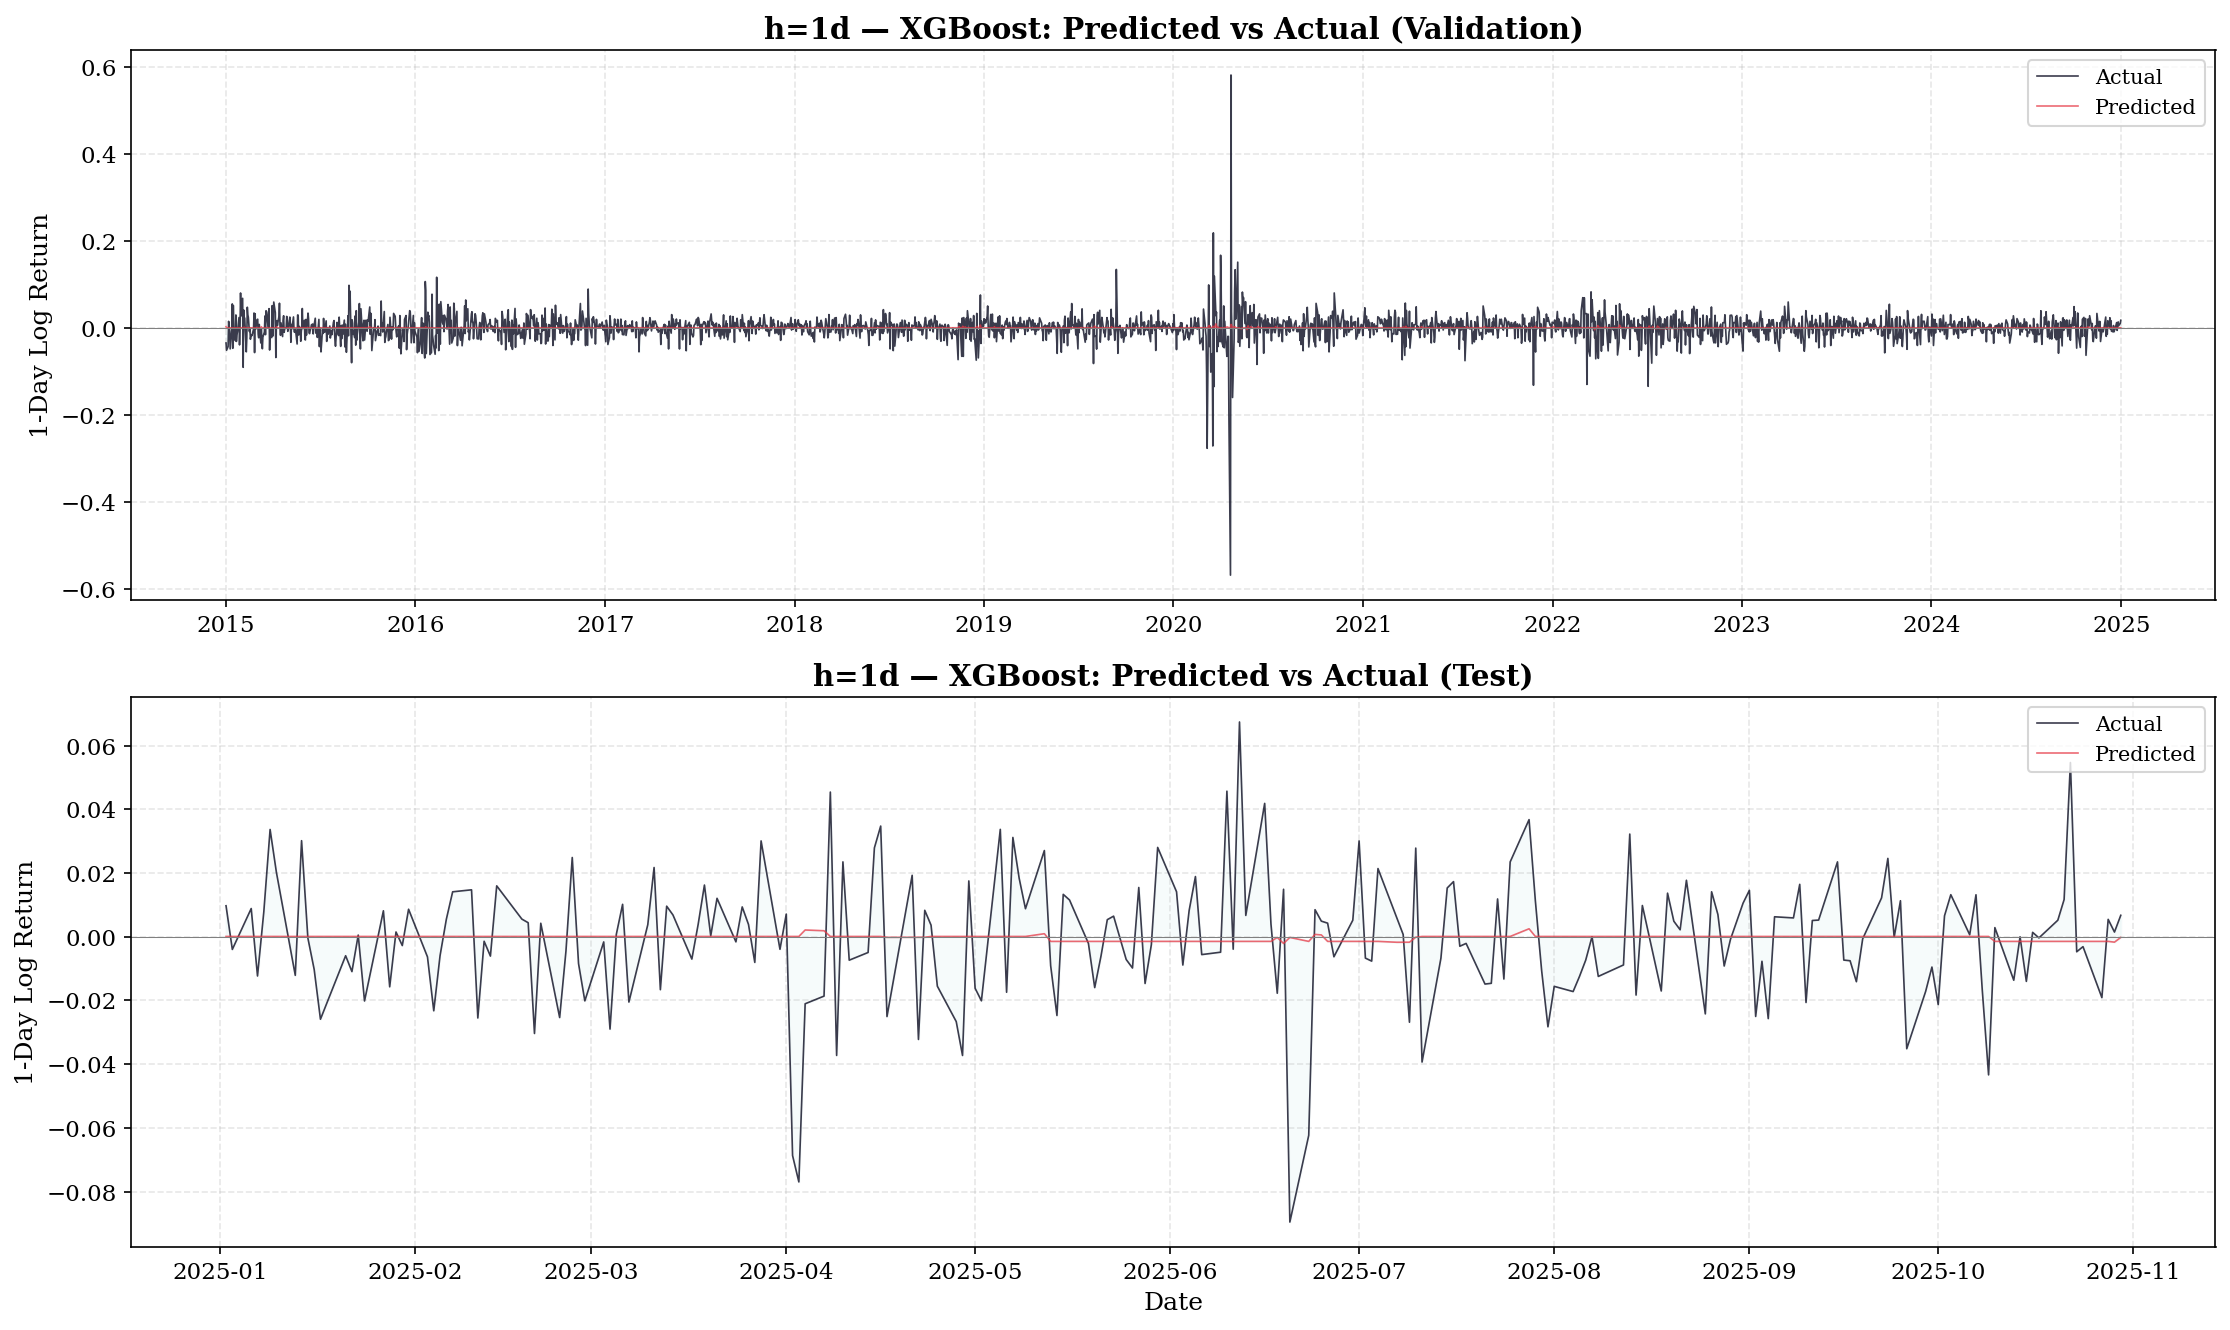

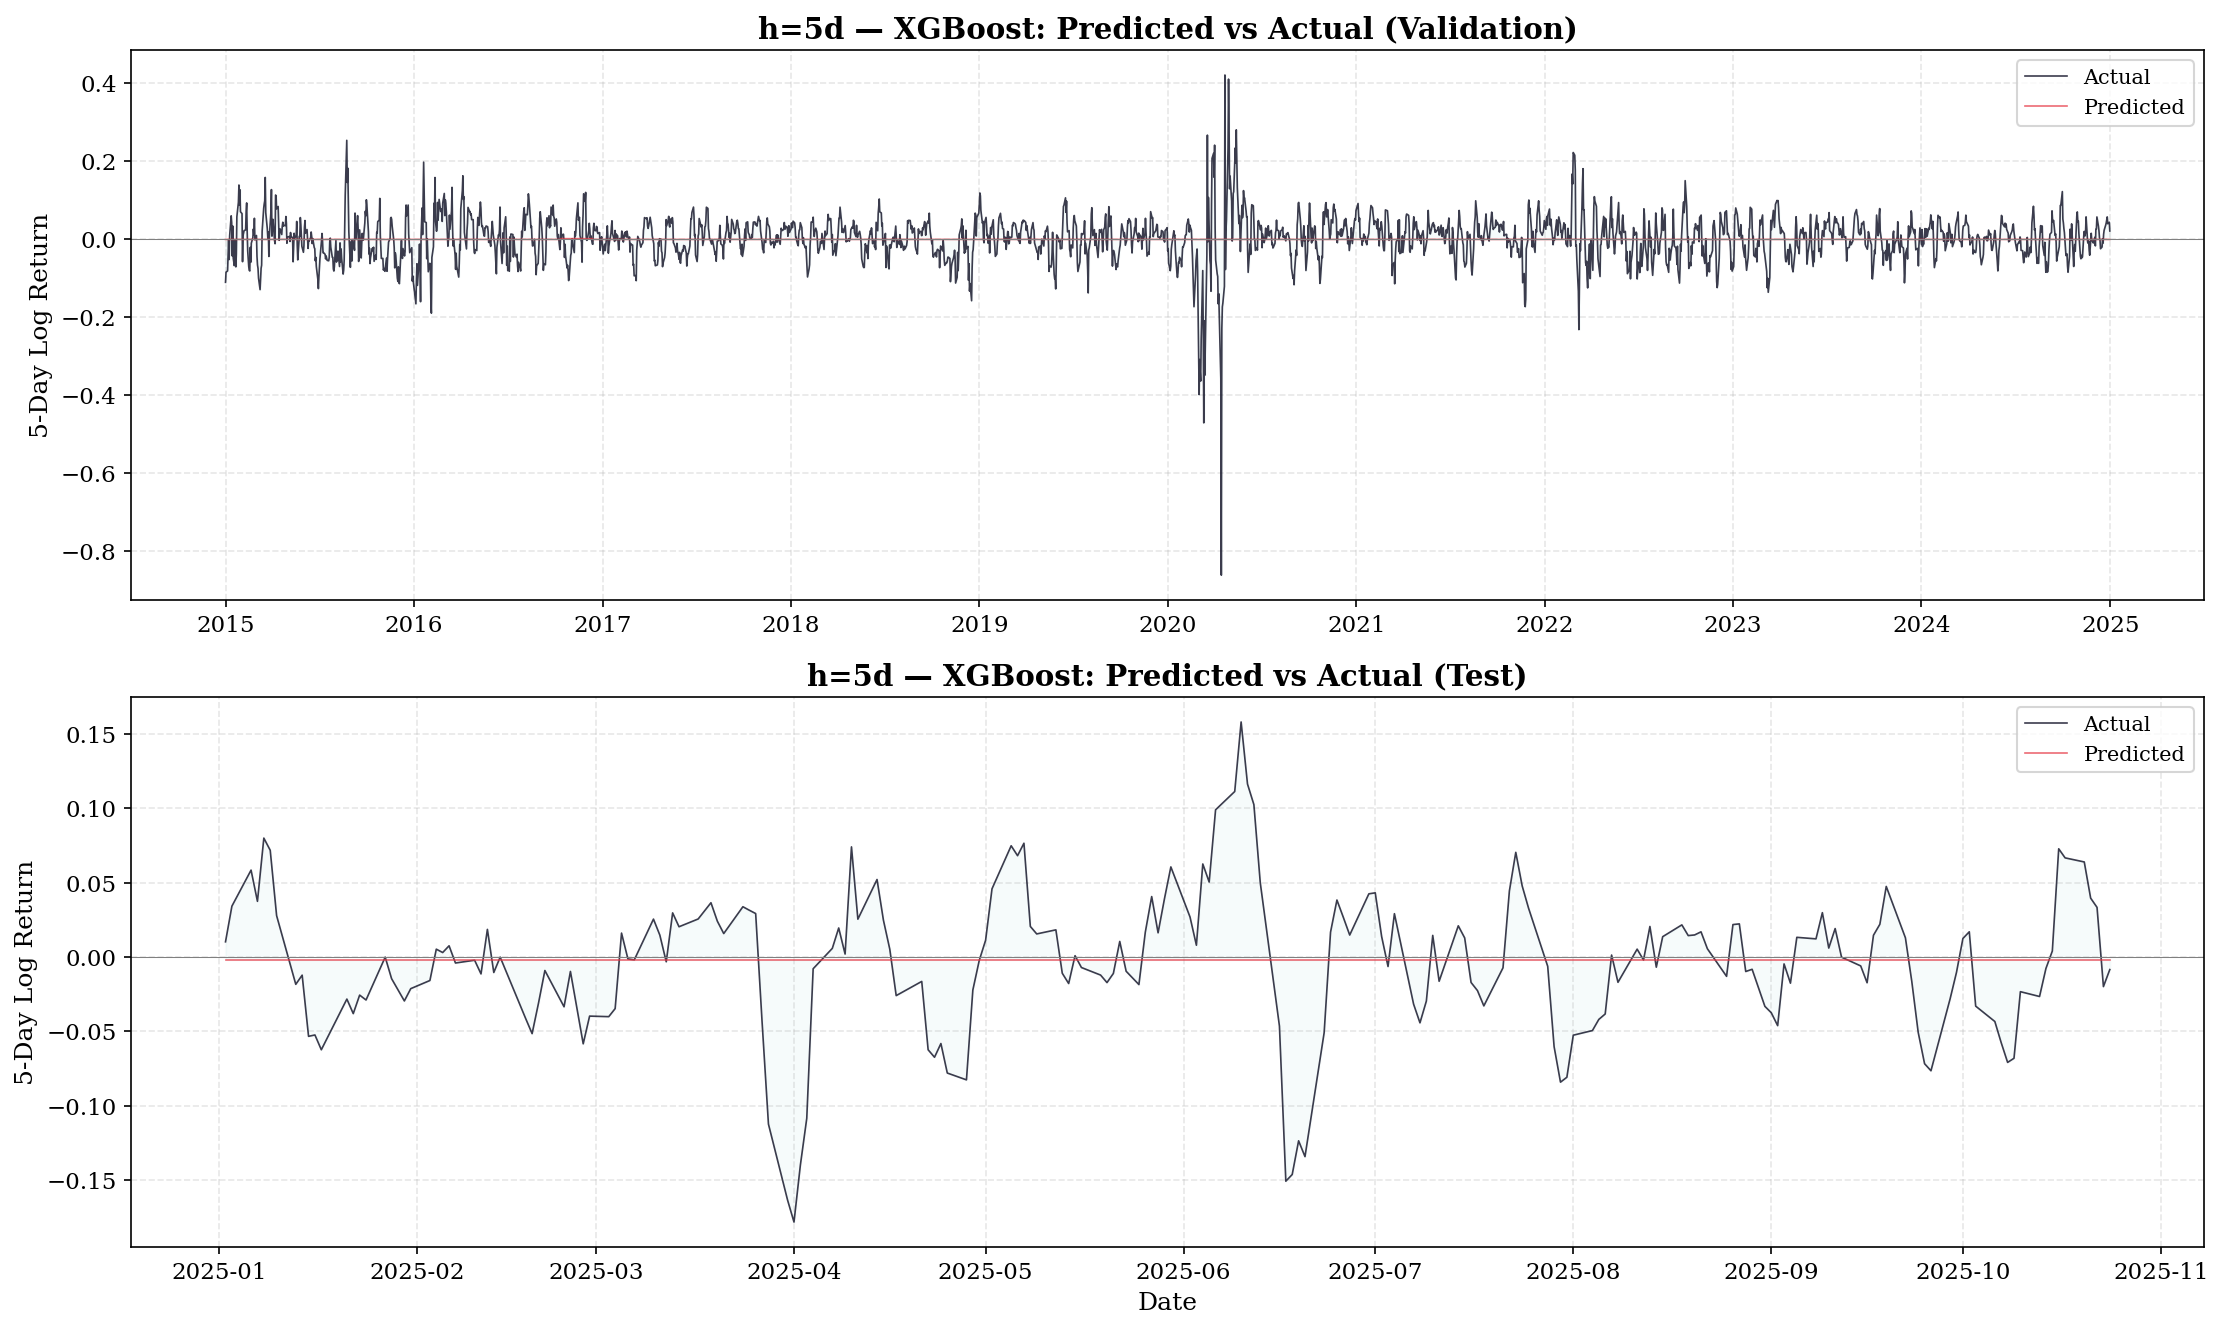

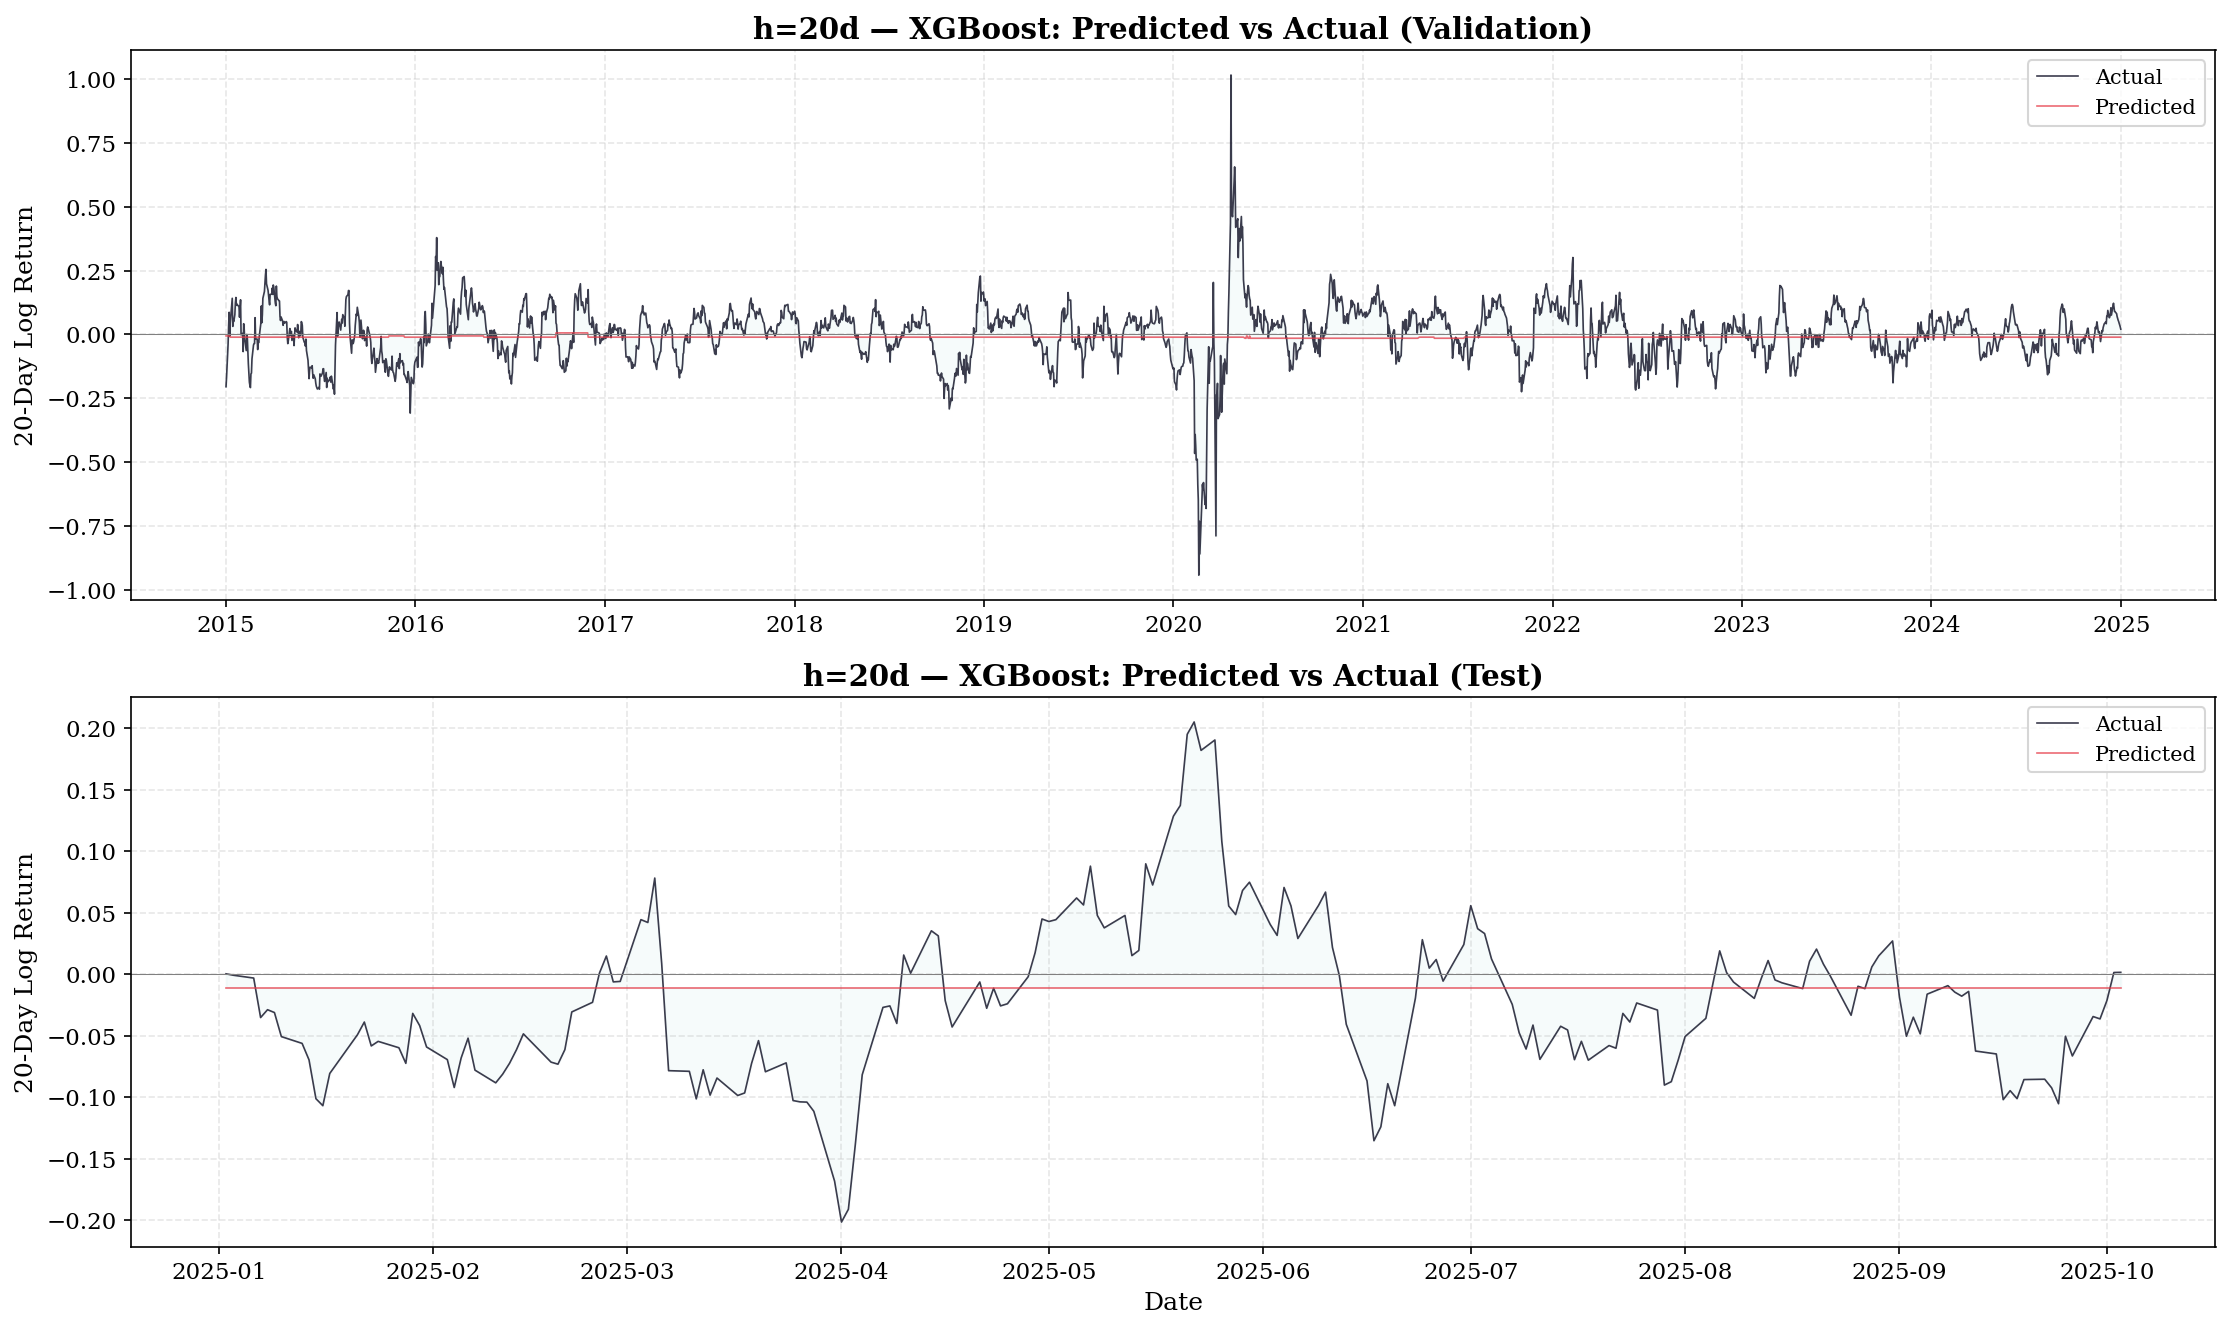

In [12]:
for h in HORIZONS:
    r = results[h]
    fig, axes = plt.subplots(2, 1, figsize=(15, 9))
    for ax, yt, yp, dates, label in [
        (axes[0], r['yva'].values, r['pred_val'], r['yva'].index, 'Validation'),
        (axes[1], r['yte'].values, r['pred_test'], r['yte'].index, 'Test'),
    ]:
        ax.plot(dates, yt, color=C['actual'], lw=0.8, alpha=0.85, label='Actual')
        ax.plot(dates, yp, color=C['pred'], lw=0.8, alpha=0.75, label='Predicted')
        ax.fill_between(dates, yt, yp, alpha=0.10, color=C['fill'])
        ax.axhline(0, color='gray', lw=0.5)
        ax.set_title(f'h={h}d — XGBoost: Predicted vs Actual ({label})', fontweight='bold')
        ax.set_ylabel(f'{h}-Day Log Return')
        ax.legend(loc='upper right')
    axes[1].set_xlabel('Date')
    plt.tight_layout(); plt.show()

## 13. Training Loss Curves

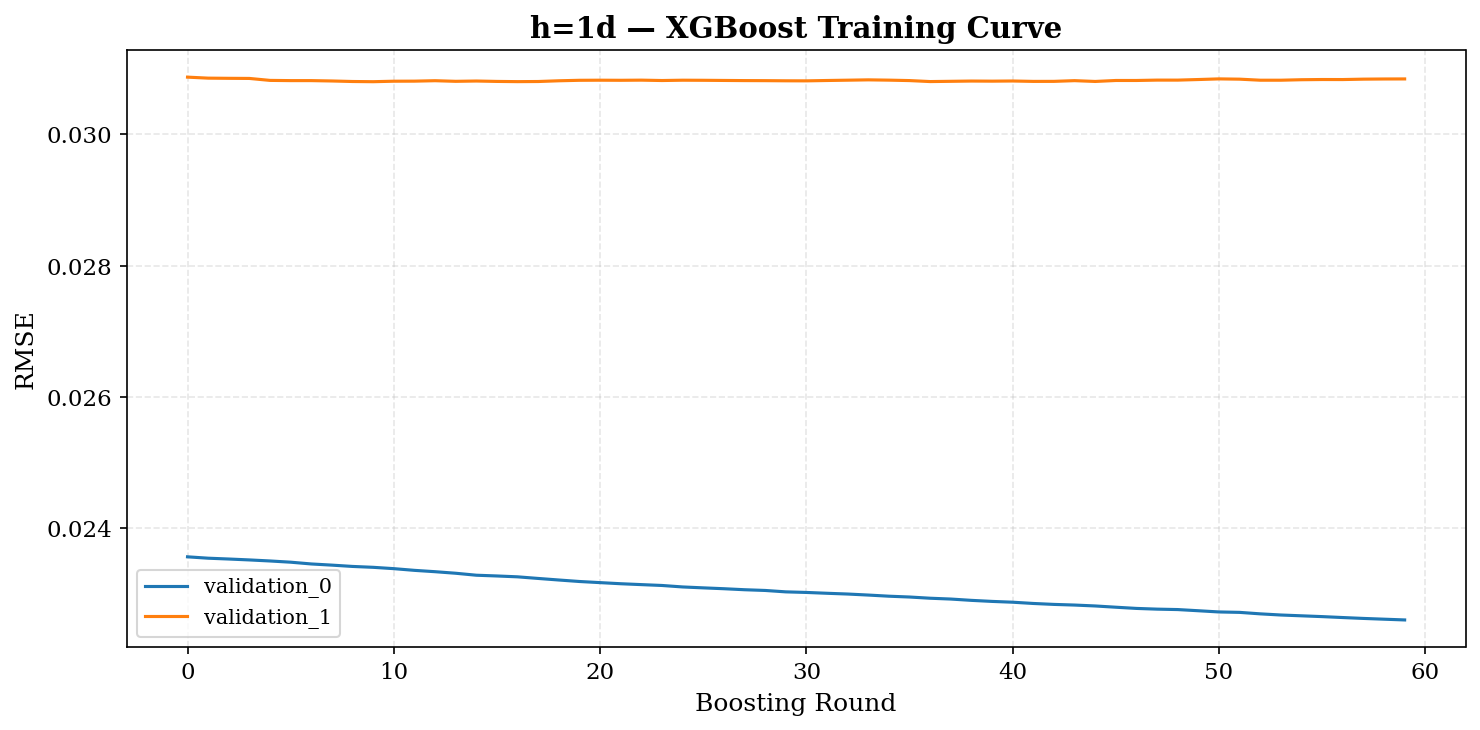

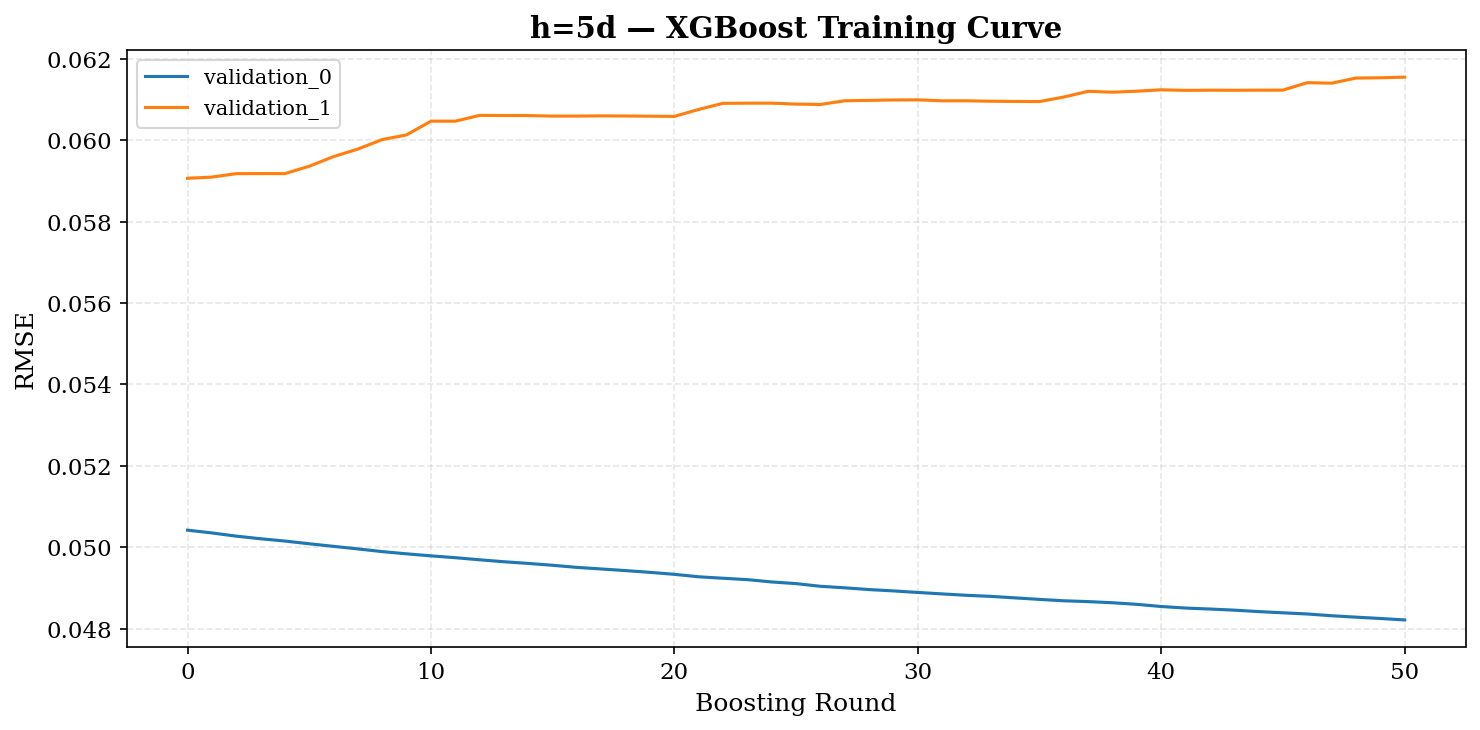

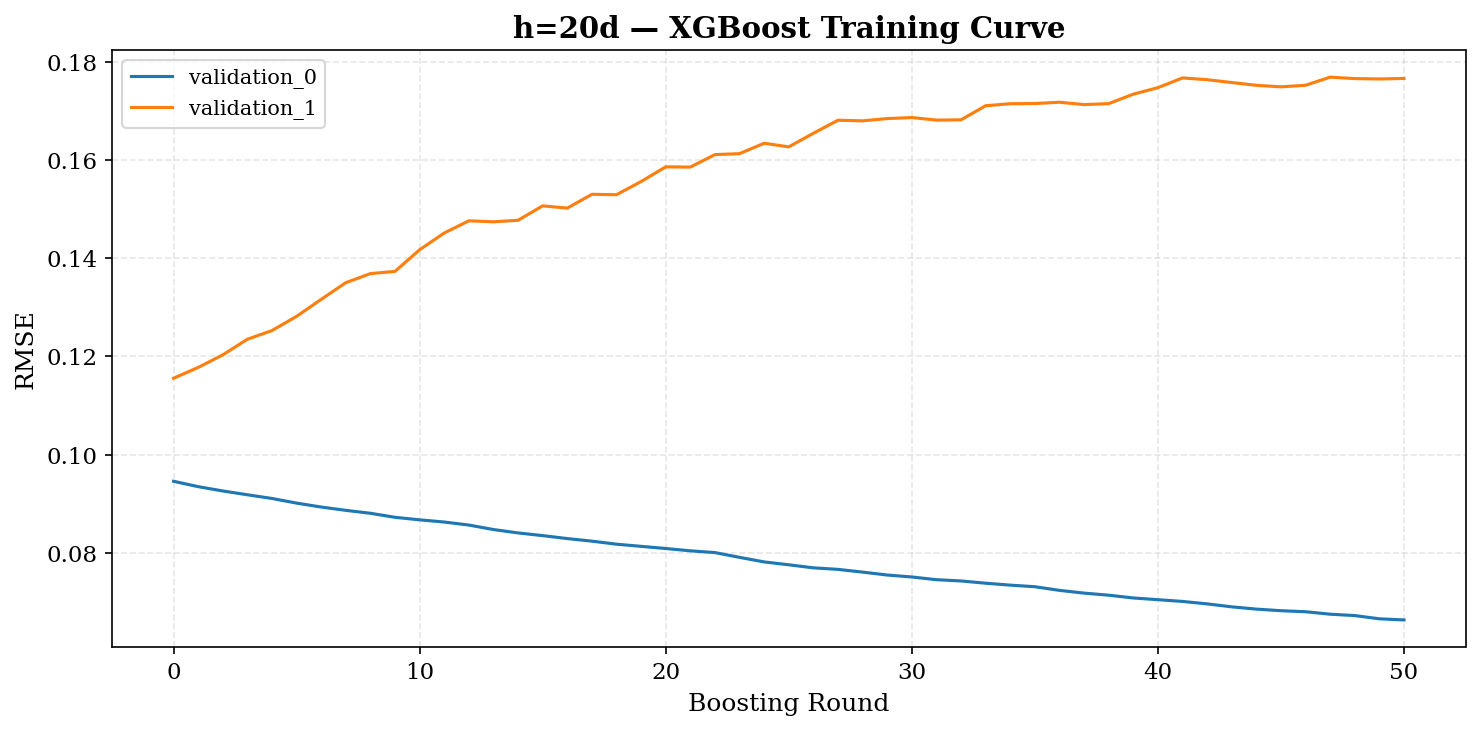

In [13]:
# ============================================================
# Training & Validation Loss Curves (from final model)
# ============================================================
for h in HORIZONS:
    r = results[h]
    if r['model'].eval_results_ is None: continue
    er = r['model'].eval_results_
    keys = list(er.keys())
    fig, ax = plt.subplots(figsize=(10, 5))
    for k in keys:
        ax.plot(er[k]['rmse'], label=k)
    ax.set_xlabel('Boosting Round'); ax.set_ylabel('RMSE')
    ax.set_title(f'h={h}d — XGBoost Training Curve', fontweight='bold')
    ax.legend(); plt.tight_layout(); plt.show()

## 14. Feature Importance

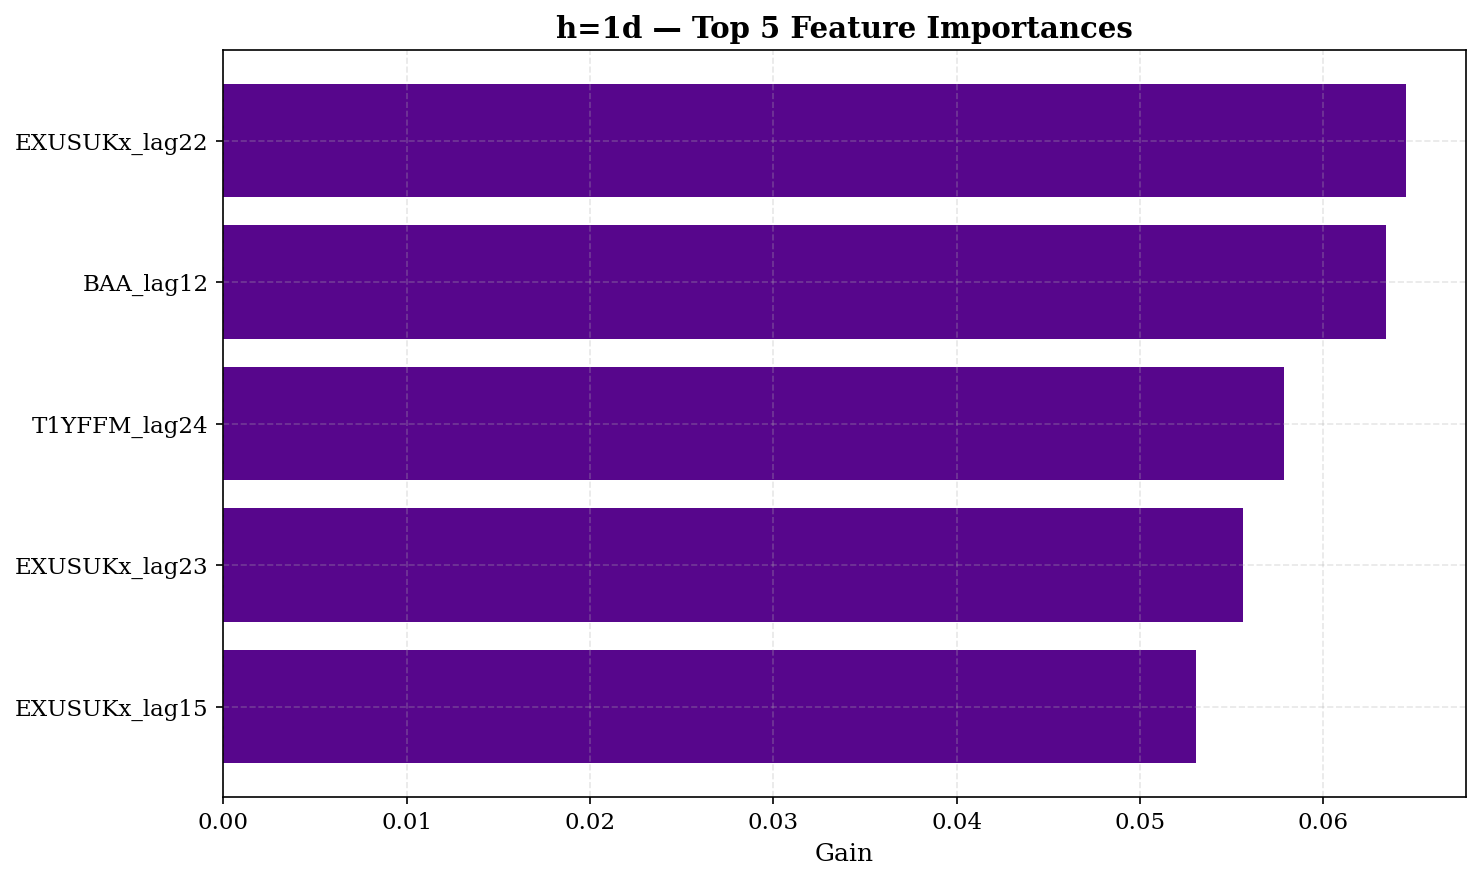

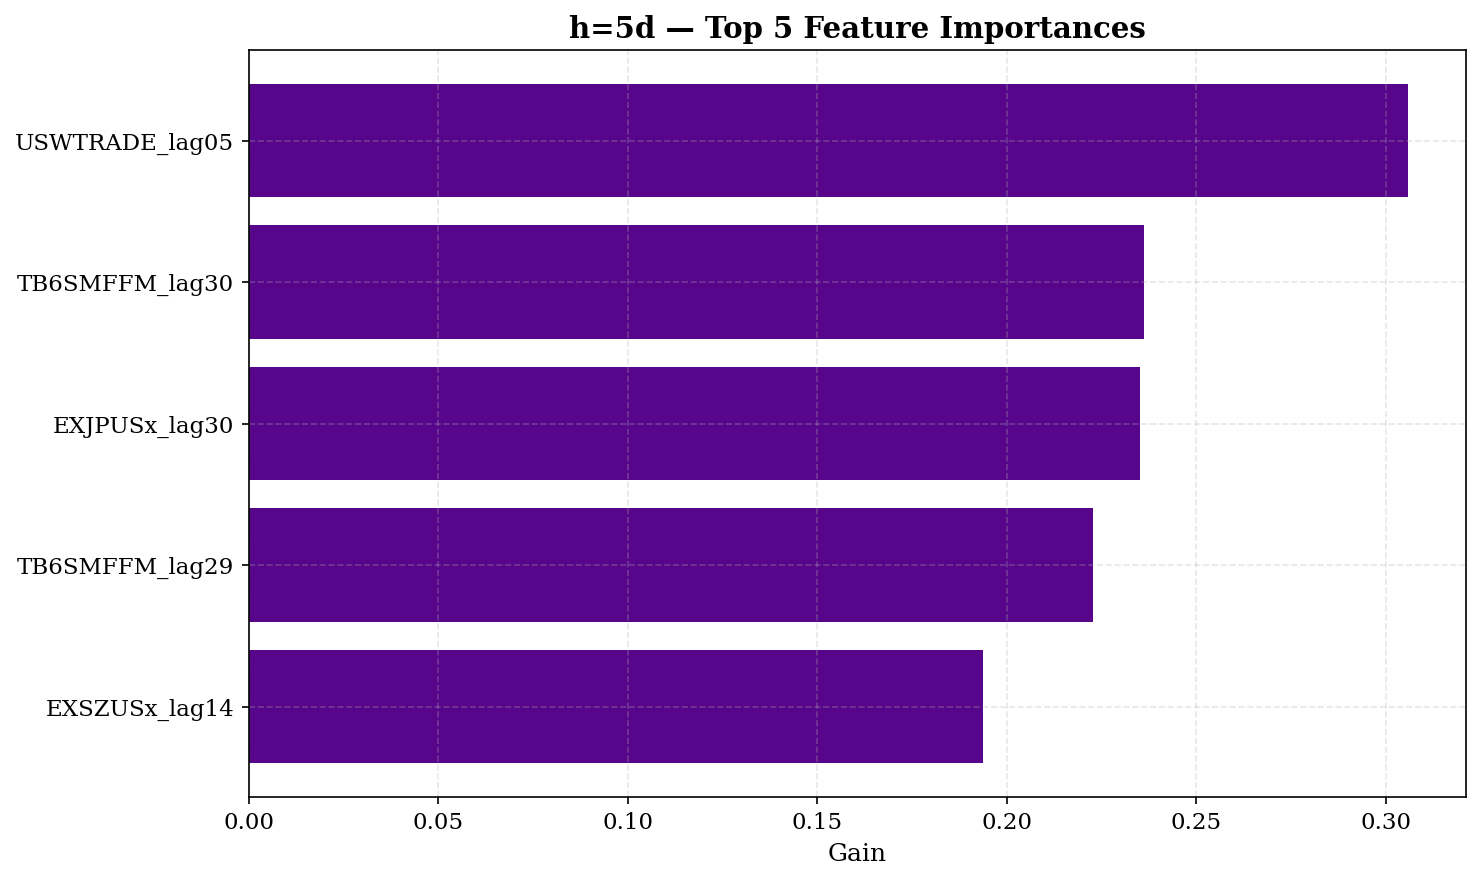

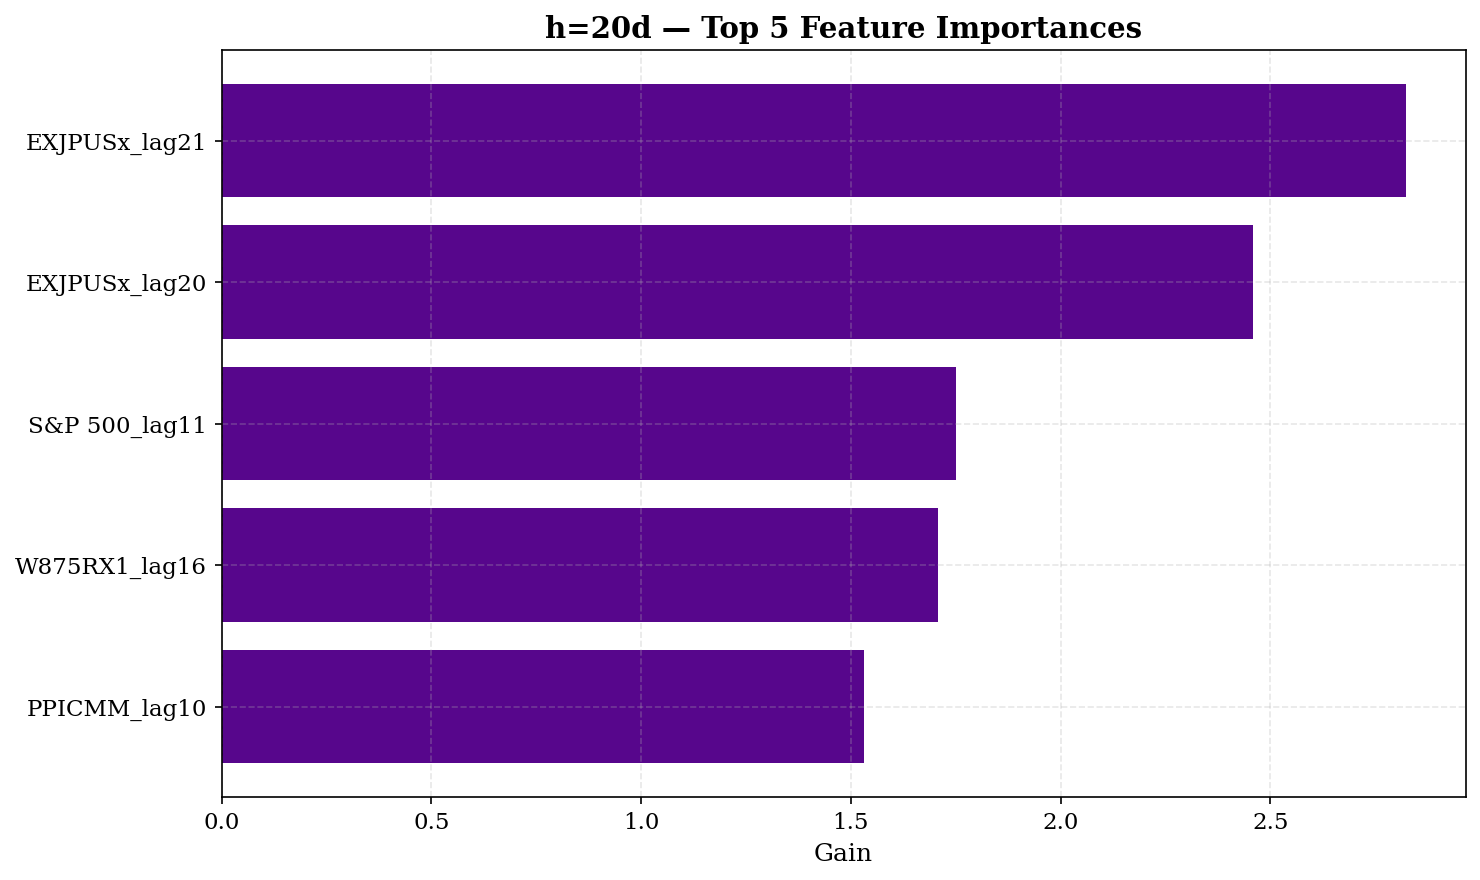

In [19]:
for h in HORIZONS:
    r = results[h]
    fi = r['model'].feature_importance(top_n=5)
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh(fi['feature'][::-1], fi['importance'][::-1], color="#57068c")
    ax.set_xlabel('Gain'); ax.set_title(f'h={h}d — Top 5 Feature Importances', fontweight='bold')
    plt.tight_layout(); plt.show()

## 15. Multi-Horizon Bar Chart

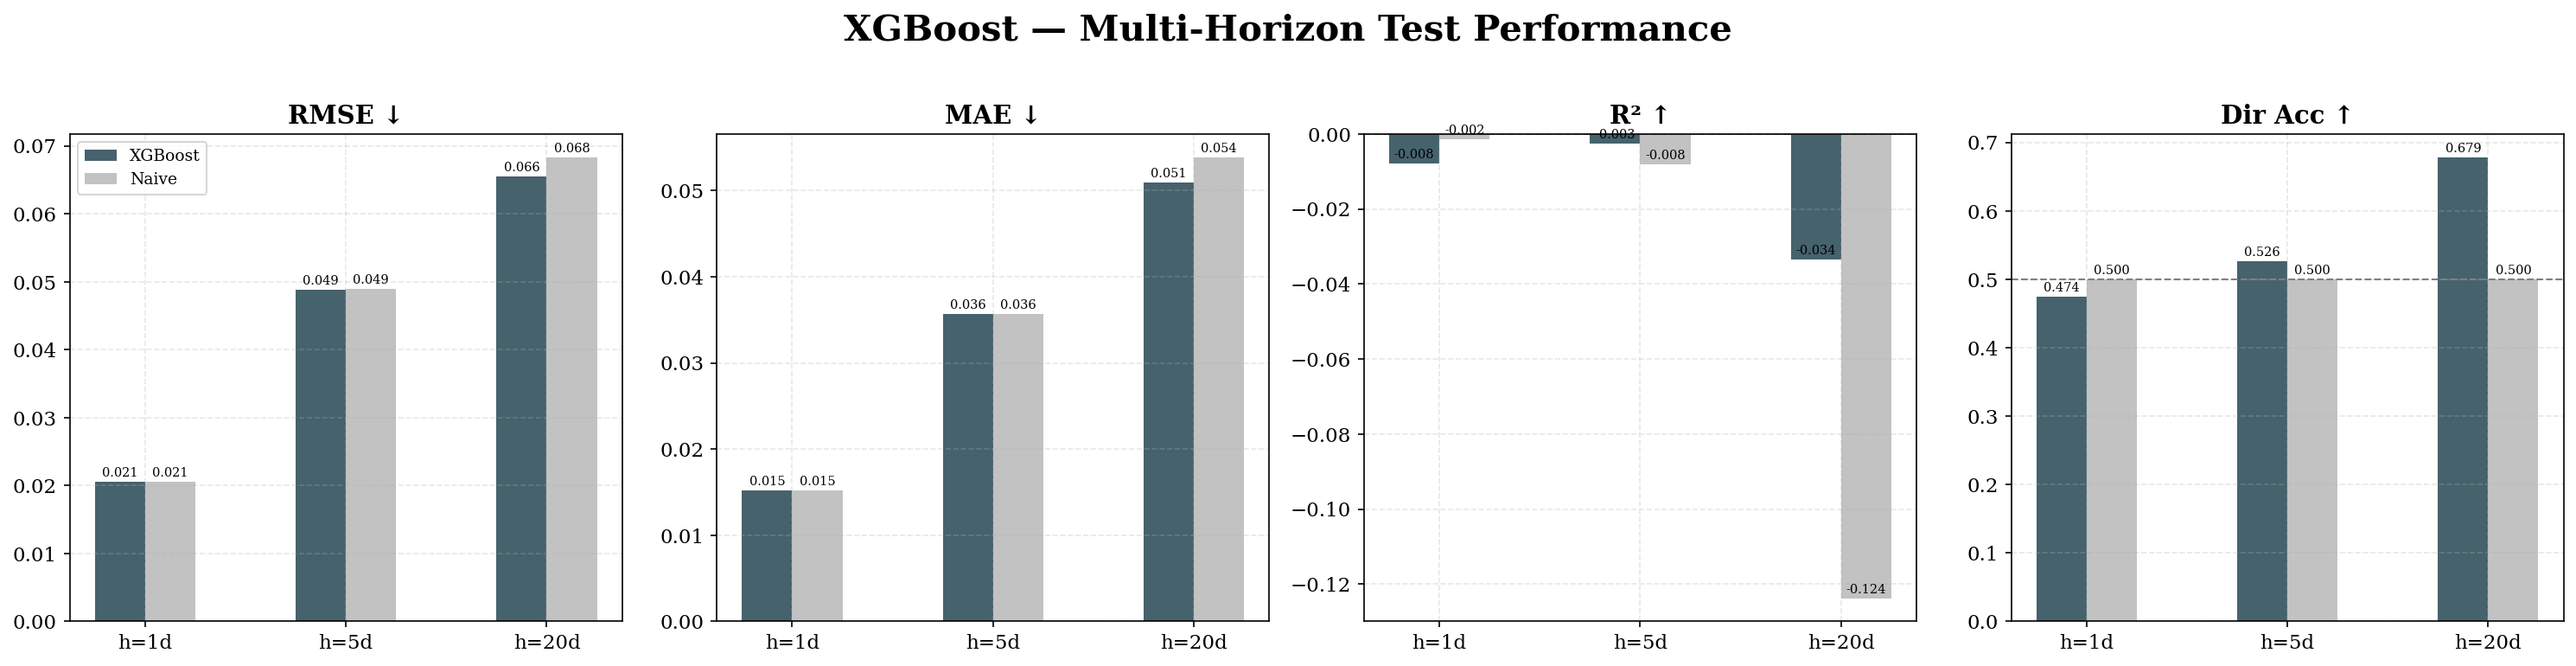

In [20]:
met_names = ['rmse', 'mae', 'r2', 'directional_acc']
titles = ['RMSE ↓', 'MAE ↓', 'R² ↑', 'Dir Acc ↑']
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
x = np.arange(len(HORIZONS)); w = 0.25
for i, (mn, title) in enumerate(zip(met_names, titles)):
    ax = axes[i]
    xgb_v = [results[h]['test_metrics'][mn] for h in HORIZONS]
    nv_v  = [results[h]['naive_test'][mn] for h in HORIZONS]
    b1 = ax.bar(x-w/2, xgb_v, w, label='XGBoost', color=C['bar1'], alpha=0.85)
    b2 = ax.bar(x+w/2, nv_v, w, label='Naive', color=C['bar3'], alpha=0.7)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(x); ax.set_xticklabels([f'h={h}d' for h in HORIZONS])
    if mn == 'directional_acc': ax.axhline(0.5, color='gray', ls='--', lw=1)
    elif mn == 'r2': ax.axhline(0, color='gray', ls='--', lw=1)
    for bar in list(b1)+list(b2):
        ht=bar.get_height()
        ax.annotate(f'{ht:.3f}',xy=(bar.get_x()+bar.get_width()/2,ht),
                    xytext=(0,3),textcoords='offset points',ha='center',fontsize=7)
    if i==0: ax.legend(fontsize=9)
plt.suptitle('XGBoost — Multi-Horizon Test Performance', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()

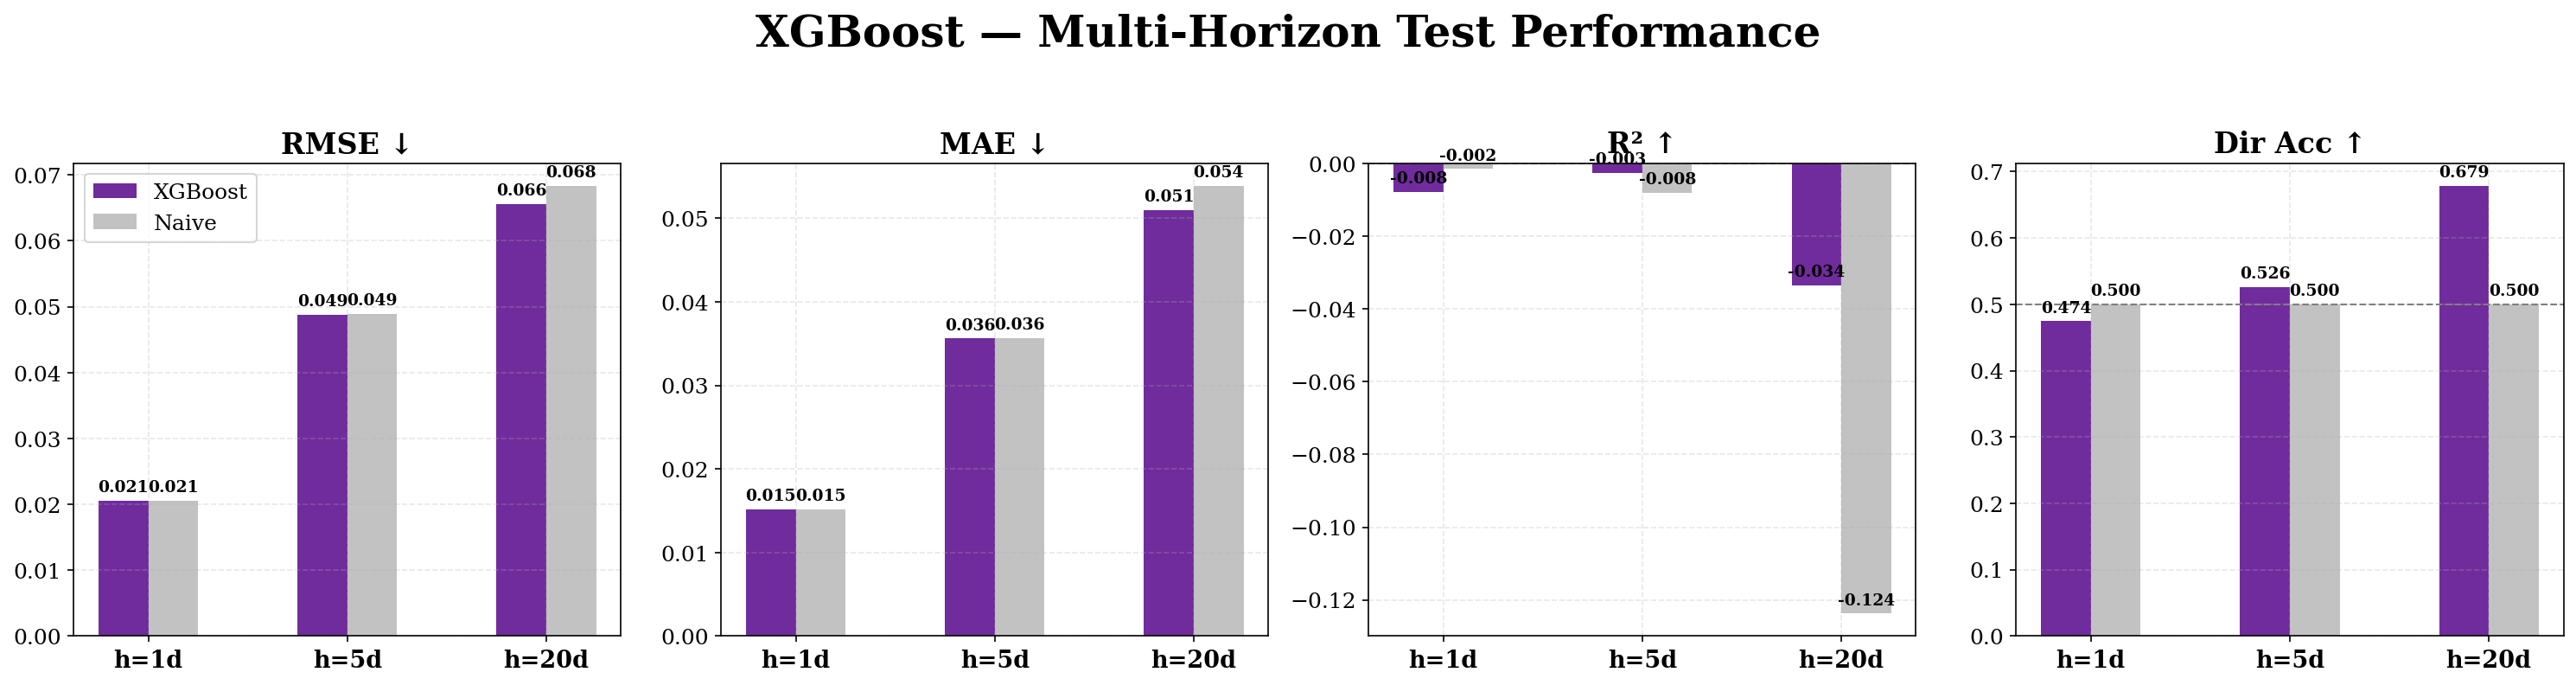

In [23]:
met_names = ['rmse', 'mae', 'r2', 'directional_acc']
titles = ['RMSE ↓', 'MAE ↓', 'R² ↑', 'Dir Acc ↑']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
x = np.arange(len(HORIZONS))
w = 0.25

for i, (mn, title) in enumerate(zip(met_names, titles)):
    ax = axes[i]

    xgb_v = [results[h]['test_metrics'][mn] for h in HORIZONS]
    nv_v  = [results[h]['naive_test'][mn] for h in HORIZONS]

    b1 = ax.bar(x-w/2, xgb_v, w, label='XGBoost',
                color="#57068c", alpha=0.85)
    b2 = ax.bar(x+w/2, nv_v, w, label='Naive',
                color='#a8a8a8', alpha=0.7)

    # Bigger + bold subplot titles
    ax.set_title(title, fontsize=16, fontweight='bold')

    # Bigger x-ticks
    ax.set_xticks(x)
    ax.set_xticklabels([f'h={h}d' for h in HORIZONS],
                       fontsize=13, fontweight='bold')

    # Bigger y-ticks
    ax.tick_params(axis='y', labelsize=12)

    if mn == 'directional_acc':
        ax.axhline(0.5, color='gray', ls='--', lw=1)
    elif mn == 'r2':
        ax.axhline(0, color='gray', ls='--', lw=1)

    # Bigger value labels
    for bar in list(b1) + list(b2):
        ht = bar.get_height()
        ax.annotate(f'{ht:.3f}',
                    xy=(bar.get_x()+bar.get_width()/2, ht),
                    xytext=(0, 5),
                    textcoords='offset points',
                    ha='center',
                    fontsize=9,
                    fontweight='bold')

    if i == 0:
        ax.legend(fontsize=12)

plt.suptitle('XGBoost — Multi-Horizon Test Performance',
             fontsize=24,
             fontweight='bold',
             y=1.05)

plt.tight_layout()
plt.show()

## 16. Summary

In [20]:
rows = []
for h in HORIZONS:
    for mn, mk in [('XGB', 'test_metrics'), ('Naive', 'naive_test')]:
        m = results[h][mk]
        rows.append({'Horizon': f'{h}d', 'Model': mn,
            'RMSE': f"{m['rmse']:.6f}", 'MAE': f"{m['mae']:.6f}",
            'R²': f"{m['r2']:.6f}", 'Dir. Acc': f"{m['directional_acc']:.4f}"})
print(pd.DataFrame(rows).to_string(index=False))

Horizon Model     RMSE      MAE        R² Dir. Acc
     1d   XGB 0.020583 0.015205 -0.007790   0.4744
     1d Naive 0.020519 0.015156 -0.001541   0.5000
     5d   XGB 0.048764 0.035631 -0.002677   0.5261
     5d Naive 0.048894 0.035674 -0.008034   0.5000
    20d   XGB 0.065558 0.050972 -0.033589   0.6786
    20d Naive 0.068357 0.053893 -0.123736   0.5000
